STEP 1

In [13]:
import geopandas as gpd
import rasterio
from rasterio import features, warp
from rasterio.enums import Resampling
from rasterio.plot import show
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET
from shapely.geometry import Point
from scipy.ndimage import binary_dilation, distance_transform_edt
import warnings

warnings.filterwarnings("ignore")
print("Bibliotheken geladen.")

Bibliotheken geladen.


# STEP 2

In [24]:
# ==========================================
# ZELLE: 1. KONFIGURATION & PFADE
# ==========================================
import geopandas as gpd
import rasterio
from rasterio import features, warp
from rasterio.enums import Resampling
from rasterio.plot import show
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import Point
from scipy.ndimage import binary_dilation, distance_transform_edt
import warnings

warnings.filterwarnings("ignore")

# --- PFADE ---
# Landnutzung
path_landuse_gb = '/Users/webshape/Library/Mobile Documents/com~apple~CloudDocs/Dateien/UCL/Spatial Analysis of Energy Data/Assessment 2/Data/Land use/FME_66316031_1765797327280_70548/data/4dd9df19-8df5-41a0-9829-8f6114e28db1/gblcm2024_10m.tif'
path_landuse_ni = '/Users/webshape/Library/Mobile Documents/com~apple~CloudDocs/Dateien/UCL/Spatial Analysis of Energy Data/Assessment 2/Data/Land use/FME_37653135_1765797423104_70463/data/db1ea1f3-4101-4a52-b2b3-582473f724ea/nilcm2024_10m.tif'

# NEU: Detailliertes Straßennetz (OpenStreetMap) für ganz UK
path_osm_england  = '/Users/webshape/Library/Mobile Documents/com~apple~CloudDocs/Dateien/UCL/Spatial Analysis of Energy Data/Assessment 2/Data/Road Network/england-260104-free.shp/gis_osm_roads_free_1.shp'
path_osm_ni       = '/Users/webshape/Library/Mobile Documents/com~apple~CloudDocs/Dateien/UCL/Spatial Analysis of Energy Data/Assessment 2/Data/Road Network/ireland-and-northern-ireland-260104-free.shp/gis_osm_roads_free_1.shp'
path_osm_scotland = '/Users/webshape/Library/Mobile Documents/com~apple~CloudDocs/Dateien/UCL/Spatial Analysis of Energy Data/Assessment 2/Data/Road Network/scotland-260104-free.shp/gis_osm_roads_free_1.shp'
path_osm_wales    = '/Users/webshape/Library/Mobile Documents/com~apple~CloudDocs/Dateien/UCL/Spatial Analysis of Energy Data/Assessment 2/Data/Road Network/wales-260104-free.shp/gis_osm_roads_free_1.shp'

# Schutzgebiete
paths_protected = [
    '/Users/webshape/Library/Mobile Documents/com~apple~CloudDocs/Dateien/UCL/Spatial Analysis of Energy Data/Assessment 2/Data/Protected Areas/GB SAC/GB_SAC_OSGB36_20250401.shp',
    '/Users/webshape/Library/Mobile Documents/com~apple~CloudDocs/Dateien/UCL/Spatial Analysis of Energy Data/Assessment 2/Data/Protected Areas/GB SPA/GB_SPA_OSGB36_20240509.shp',
    '/Users/webshape/Library/Mobile Documents/com~apple~CloudDocs/Dateien/UCL/Spatial Analysis of Energy Data/Assessment 2/Data/Protected Areas/NI SAC/NI_SAC_TM65_20191031.shp',
    '/Users/webshape/Library/Mobile Documents/com~apple~CloudDocs/Dateien/UCL/Spatial Analysis of Energy Data/Assessment 2/Data/Protected Areas/NI SPA/NI_SPA_TM65_20171114.shp'
]

path_wind_tif = '/Users/webshape/Library/Mobile Documents/com~apple~CloudDocs/Dateien/UCL/Spatial Analysis of Energy Data/Assessment 2/Data/Wind Speed/GBR_wind-speed_150m (1).tif'
path_transmission_lines = '/Users/webshape/Library/Mobile Documents/com~apple~CloudDocs/Dateien/UCL/Spatial Analysis of Energy Data/Assessment 2/Data/Transmission Lines/GridUK275kV-iflenght>=200.geojson'

paths_slope = [
    '/Users/webshape/Library/Mobile Documents/com~apple~CloudDocs/Dateien/UCL/Spatial Analysis of Energy Data/Assessment 2/Data/Slopes/w001001.adf',
    '/Users/webshape/Library/Mobile Documents/com~apple~CloudDocs/Dateien/UCL/Spatial Analysis of Energy Data/Assessment 2/Data/Slopes/NI/viz.SRTMGL1_slope.tif'
]

# --- PARAMETER ---
ALLOWED_LULC_IDS = [3, 4, 5, 6, 7, 9, 10]
URBAN_LULC_IDS = [20, 21] 

# Pufferzonen (Minimale Abstände)
BUFFER_URBAN_EC = 1125
BUFFER_PROTECTED_EC = 550
BUFFER_TRANSMISSION_EC = 160
BUFFER_ROADS_EC = 220 

# Maximale Abstände (Anschlusskriterien)
MAX_DIST_GRID_EC = 30000       # > 7.4 km vom Netz ist Ausschluss
MAX_DIST_ROAD_EC = 6335       # > 6.3 km von Straße ist Ausschluss (Jetzt möglich dank OSM!)

MIN_WIND_SPEED_EC = 5.2
MAX_SLOPE_DEG_EC = 5.71

# Gewichte (Weights) für Scoring
WEIGHTS = {
    'C1_Wind': 0.402,
    'C2_Road': 0.122,
    'C3_Grid': 0.122,
    'C4_Urban': 0.122,
    'C5_Slope': 0.116,
    'C6_Prot': 0.116
}

# System
SCALE_FACTOR = 0.15   
TARGET_CRS = "EPSG:27700"

print("Konfiguration geladen (inkl. 4 OSM-Straßenfiles).")

Konfiguration geladen (inkl. 4 OSM-Straßenfiles).


# STEP 3

In [25]:
def calculate_distance_raster(shapes, shape_meta, target_shape, target_transform):
    """Berechnet euklidische Distanz zu Shapes in Metern."""
    feature_mask = features.rasterize(
        shapes=shapes,
        out_shape=target_shape,
        transform=target_transform,
        default_value=1,
        fill=0,
        dtype=np.uint8
    )
    # Invertieren: 0=Feature, 1=Hintergrund
    dist_input = 1 - feature_mask
    dist_px = distance_transform_edt(dist_input)
    # Pixelgröße holen (für Umrechnung in Meter)
    pixel_size = target_transform[0]
    return (dist_px * pixel_size).astype(np.float32)

def reclassify_raster(raster_array, conditions, scores):
    """Wrapper für np.select."""
    return np.select(conditions, scores, default=1).astype(np.uint8)

def get_combined_bounds_and_meta(raster_paths, scale, target_crs):
    """Berechnet die Größe des Master-Grids für GB & NI."""
    min_x, min_y, max_x, max_y = float('inf'), float('inf'), float('-inf'), float('-inf')
    
    # 1. Bounds scannen
    for p in raster_paths:
        try:
            with rasterio.open(p) as src:
                transform, width, height = warp.calculate_default_transform(
                    src.crs, target_crs, src.width, src.height, *src.bounds)
                min_x = min(min_x, transform[2])
                max_y = max(max_y, transform[5])
                max_x = max(max_x, transform[2] + width * transform[0])
                min_y = min(min_y, transform[5] + height * transform[4])
        except Exception as e:
            print(f"Fehler bei {p}: {e}")

    # 2. Grid definieren
    with rasterio.open(raster_paths[0]) as src:
        pixel_size_x = src.transform[0] / scale
        pixel_size_y = -src.transform[4] / scale
    
    out_width = int((max_x - min_x) / pixel_size_x)
    out_height = int((max_y - min_y) / pixel_size_y)
    out_transform = rasterio.Affine(pixel_size_x, 0, min_x, 0, -pixel_size_y, max_y)
    
    meta = {
        'driver': 'GTiff', 'height': out_height, 'width': out_width,
        'transform': out_transform, 'crs': target_crs,
        'count': 1, 'dtype': rasterio.uint8
    }
    return meta

print("Funktionen definiert.")

Funktionen definiert.


# STEP 4

In [26]:
# ==========================================
# ZELLE 5: MASTER-GRID ERSTELLEN
# ==========================================
print("Erstelle Master-Grid (GB & NI)...")

def get_combined_bounds_and_meta(raster_paths, scale, target_crs):
    min_x, min_y, max_x, max_y = float('inf'), float('inf'), float('-inf'), float('-inf')
    for p in raster_paths:
        try:
            with rasterio.open(p) as src:
                transform, width, height = warp.calculate_default_transform(
                    src.crs, target_crs, src.width, src.height, *src.bounds)
                min_x = min(min_x, transform[2])
                max_y = max(max_y, transform[5])
                max_x = max(max_x, transform[2] + width * transform[0])
                min_y = min(min_y, transform[5] + height * transform[4])
        except Exception as e:
            print(f"Fehler bei {p}: {e}")
            
    with rasterio.open(raster_paths[0]) as src:
        pixel_size_x = src.transform[0] / scale
        pixel_size_y = -src.transform[4] / scale
    
    out_width = int((max_x - min_x) / pixel_size_x)
    out_height = int((max_y - min_y) / pixel_size_y)
    out_transform = rasterio.Affine(pixel_size_x, 0, min_x, 0, -pixel_size_y, max_y)
    
    return {'driver': 'GTiff', 'height': out_height, 'width': out_width,
            'transform': out_transform, 'crs': target_crs, 'count': 1, 'dtype': rasterio.uint8}

# 1. Canvas definieren
raster_list = [path_landuse_gb, path_landuse_ni]
out_meta = get_combined_bounds_and_meta(raster_list, SCALE_FACTOR, TARGET_CRS)
master_shape = (out_meta['height'], out_meta['width'])
master_transform = out_meta['transform']
px_size = master_transform[0]

print(f"Grid Größe: {master_shape}")

# 2. Landnutzung laden
lulc_data = np.zeros(master_shape, dtype=np.uint8)
for p in raster_list:
    try:
        with rasterio.open(p) as src:
            temp = np.zeros(master_shape, dtype=np.uint8)
            warp.reproject(rasterio.band(src, 1), temp, src_transform=src.transform, src_crs=src.crs, dst_transform=master_transform, dst_crs=out_meta['crs'], resampling=Resampling.nearest, dst_nodata=0)
            lulc_data = np.maximum(lulc_data, temp)
    except: pass

print("Master-Grid erstellt.")

Erstelle Master-Grid (GB & NI)...
Grid Größe: (19500, 10702)
Master-Grid erstellt.


In [27]:
import pandas as pd
import geopandas as gpd
import os

# --- PFADE DEFINIEREN ---
wind_csv_path = '/Users/webshape/Library/Mobile Documents/com~apple~CloudDocs/Dateien/UCL/Spatial Analysis of Energy Data/Assessment 2/Data/Current Wind Mills/Current Wind mills.csv'

base_path_pv = '/Users/webshape/Library/Mobile Documents/com~apple~CloudDocs/Dateien/UCL/Spatial Analysis of Energy Data/Assessment 2/Data/Current PV/'

pv_files = {
    "Wales": base_path_pv + 'Current PV Wales.geojson',
    "England 1": base_path_pv + 'Curren PV England 1.geojson',
    "England 2": base_path_pv + 'Current PV England 2.geojson',
    "Northern Ireland": base_path_pv + 'Current PV Northern Irleland.geojson',
    "Scotland": base_path_pv + 'Current PV Scotland.geojson'
}

def load_uk_data_v2():
    print("--- Starte Datenimport für 'spatial assessemnt' (CSV-Mode) ---")
    
    # 1. WIND DATEN (CSV)
    try:
        # Einlesen der CSV mit @lat und @lon
        df_wind = pd.read_csv(wind_csv_path)
        gdf_wind = gpd.GeoDataFrame(
            df_wind, 
            geometry=gpd.points_from_xy(df_wind['@lon'], df_wind['@lat']),
            crs="EPSG:4326"
        )
        print(f"✅ Wind-Daten geladen: {len(gdf_wind)} Standorte.")
    except Exception as e:
        print(f"❌ Fehler beim Laden der Wind-CSV: {e}")
        gdf_wind = gpd.GeoDataFrame()

    # 2. PV DATEN (GEOJSON)
    pv_list = []
    regional_stats = []

    for region, path in pv_files.items():
        if os.path.exists(path):
            try:
                gdf_temp = gpd.read_file(path)
                gdf_temp['source_region'] = region
                pv_list.append(gdf_temp)
                regional_stats.append({"Region": region, "Anzahl": len(gdf_temp), "Status": "Geladen"})
            except Exception as e:
                regional_stats.append({"Region": region, "Anzahl": 0, "Status": f"Fehler: {e}"})
        else:
            regional_stats.append({"Region": region, "Anzahl": 0, "Status": "Datei nicht gefunden"})

    # Kombinieren der PV-Daten
    if pv_list:
        gdf_pv_all = pd.concat(pv_list, ignore_index=True)
        if gdf_pv_all.crs is None:
            gdf_pv_all.set_crs("EPSG:4326", inplace=True)
    else:
        gdf_pv_all = gpd.GeoDataFrame()

    # 3. STATISTIK AUSGEBEN
    print("\n### Regionale PV-Übersicht ###")
    print(pd.DataFrame(regional_stats).to_string(index=False))
    
    print("\n### Gesamt-Statistik ###")
    summary = {
        "Kategorie": ["Wind (Punkte)", "PV (Flächen/Linien)"],
        "Anzahl": [len(gdf_wind), len(gdf_pv_all)],
        "Fehlende Geometrie": [gdf_wind.geometry.isna().sum(), gdf_pv_all.geometry.isna().sum()],
        "CRS": [str(gdf_wind.crs), str(gdf_pv_all.crs)]
    }
    print(pd.DataFrame(summary).to_string(index=False))

    return gdf_wind, gdf_pv_all

# Daten laden
wind_uk, pv_uk = load_uk_data_v2()

--- Starte Datenimport für 'spatial assessemnt' (CSV-Mode) ---
✅ Wind-Daten geladen: 12435 Standorte.

### Regionale PV-Übersicht ###
          Region  Anzahl  Status
           Wales   14337 Geladen
       England 1   11121 Geladen
       England 2   57576 Geladen
Northern Ireland    2291 Geladen
        Scotland   15672 Geladen

### Gesamt-Statistik ###
          Kategorie  Anzahl  Fehlende Geometrie       CRS
      Wind (Punkte)   12435                   0 EPSG:4326
PV (Flächen/Linien)  100997                   0 EPSG:4326


# STEP 5 

In [28]:
# ==========================================
# ZELLE 6: AUSSCHLUSS-MASKE (INKL. OSM LOAD)
# ==========================================
import pandas as pd # Sicherstellen, dass pandas da ist

print("Berechne Ausschluss-Maske (inkl. 4 OSM-Dateien)...")

# --- INITIALISIERUNG ---
exclusion_mask = np.zeros(master_shape, dtype=np.uint8)
exclusion_mask[np.isin(lulc_data, ALLOWED_LULC_IDS)] = 1

# Hilfsfunktion Distanz
def calc_dist_layer(shapes):
    if shapes is None or shapes.empty: return np.zeros(master_shape) + 99999
    mask = features.rasterize(shapes, out_shape=master_shape, transform=master_transform, default_value=1, fill=0)
    return distance_transform_edt(1 - mask) * px_size

# 1. URBAN (EC 1)
print("   - Maskiere Urban Areas...")
mask_urban = binary_dilation(np.isin(lulc_data, URBAN_LULC_IDS), iterations=int(BUFFER_URBAN_EC / px_size))
exclusion_mask[mask_urban] = 0

# Vektordaten global speichern
gdf_prot_all, gdf_lines_all, gdf_roads_all = None, None, None

# 2. SCHUTZGEBIETE (EC 2)
print("   - Maskiere Schutzgebiete...")
gdfs_prot = []
for p in paths_protected:
    try: gdfs_prot.append(gpd.read_file(p).to_crs(out_meta['crs']))
    except: pass
if gdfs_prot:
    gdf_prot_all = pd.concat(gdfs_prot, ignore_index=True)
    mask_prot = features.rasterize(gdf_prot_all.geometry.buffer(BUFFER_PROTECTED_EC), out_shape=master_shape, transform=master_transform, default_value=1)
    exclusion_mask[mask_prot == 1] = 0

# 3. OSM STRASSEN (EC 3) - Der komplexe Teil
print("   - Lade OSM-Straßen (England, Scotland, Wales, NI)...")
KEEP_TYPES = [
    'motorway', 'motorway_link', 'trunk', 'trunk_link', 
    'primary', 'primary_link', 'secondary', 'secondary_link', 
    'tertiary', 'tertiary_link', 'unclassified', 'residential', 
    'service', 'track' # Feldwege!
]

def load_osm_part(path, name):
    try:
        print(f"     ... lese {name}")
        df = gpd.read_file(path, engine='pyogrio', columns=['fclass', 'geometry'])
        if 'fclass' in df.columns:
            df = df[df['fclass'].isin(KEEP_TYPES)]
        return df.to_crs(out_meta['crs'])
    except Exception as e:
        print(f"     FEHLER bei {name}: {e}")
        return None

# Alle 4 Teile laden
gdf_eng = load_osm_part(path_osm_england, "England")
gdf_ni  = load_osm_part(path_osm_ni, "N. Ireland")
gdf_sco = load_osm_part(path_osm_scotland, "Scotland")
gdf_wal = load_osm_part(path_osm_wales, "Wales")

parts = [g for g in [gdf_eng, gdf_ni, gdf_sco, gdf_wal] if g is not None]

if parts:
    gdf_roads_all = pd.concat(parts, ignore_index=True)
    print(f"     -> {len(gdf_roads_all)} Straßenabschnitte kombiniert.")
    
    # Distanz & Filter
    dist_roads_m = calc_dist_layer(gdf_roads_all.geometry)
    exclusion_mask[dist_roads_m < BUFFER_ROADS_EC] = 0
    exclusion_mask[dist_roads_m > MAX_DIST_ROAD_EC] = 0
    print("     -> Straßenfilter angewendet.")
else:
    print("     KRITISCH: Keine Straßendaten geladen!")
    dist_roads_m = np.zeros(master_shape)

# Aufräumen
del gdf_eng, gdf_ni, gdf_sco, gdf_wal

# 4. STROMNETZ (EC 6)
print("   - Maskiere Stromnetz...")
try:
    gdf_lines_all = gpd.read_file(path_transmission_lines).to_crs(out_meta['crs'])
    dist_grid_m = calc_dist_layer(gdf_lines_all.geometry)
    exclusion_mask[dist_grid_m < BUFFER_TRANSMISSION_EC] = 0
    exclusion_mask[dist_grid_m > MAX_DIST_GRID_EC] = 0
except Exception as e: print(f"     Fehler Grid: {e}")

# 5. WIND & SLOPE
print("   - Maskiere Wind & Slope...")
raw_slope_deg = np.zeros(master_shape, dtype=np.float32)
for p in paths_slope:
    try:
        with rasterio.open(p) as src:
            temp = np.zeros(master_shape, dtype=np.float32)
            warp.reproject(rasterio.band(src, 1), temp, src_transform=src.transform, src_crs=src.crs, dst_transform=master_transform, dst_crs=out_meta['crs'], resampling=Resampling.bilinear)
            raw_slope_deg = np.maximum(raw_slope_deg, temp)
    except: pass
exclusion_mask[raw_slope_deg >= MAX_SLOPE_DEG_EC] = 0

raw_wind = np.zeros(master_shape, dtype=np.float32)
try:
    with rasterio.open(path_wind_tif) as src_wind:
        warp.reproject(rasterio.band(src_wind, 1), raw_wind, src_transform=src_wind.transform, src_crs=src_wind.crs, dst_transform=master_transform, dst_crs=out_meta['crs'], resampling=Resampling.bilinear)
    exclusion_mask[raw_wind <= MIN_WIND_SPEED_EC] = 0
except: pass

# ==========================================\n
# NEU: 6. UAS (DROHNEN-ZONEN) EXCLUSION
# ==========================================\n
print("   - Maskiere UAS-Zonen (Drohnen)...")
path_uas = '/Users/webshape/Library/Mobile Documents/com~apple~CloudDocs/Dateien/UCL/Spatial Analysis of Energy Data/Assessment 2/Data/UAS/EG_UAS_FR_DS_AREA1_FULL_20251225_XML/EG_UAS_FR_DS_AREA1_FULL_20251225.xml'

NON_AVIATION_KEYWORDS = [
    'HIGHLANDS',
    'RPAS CORRIDOR',
    'NORTHERN COMPLEX' # Gebiete, die ignoriert werden (kein Ausschluss)
]

# ==========================================
# VERBESSERTE UAS-VERARBEITUNG
# ==========================================
import os

print("   - Maskiere UAS-Zonen (Drohnen)...")

# GDAL-Option setzen, um fehlerhafte Geometrien zu überspringen
os.environ['GML_SKIP_CORRUPTED_FEATURES'] = 'YES'

try:
    # Wir nutzen das 'fiona' oder 'pyogrio' engine explizit
    # Falls es weiterhin kracht, versuchen wir nur die Geometrie zu laden
    gdf_uas = gpd.read_file(path_uas, engine='pyogrio')

    if not gdf_uas.empty:
        # Spaltennamen normalisieren (AIXM Spalten sind oft sehr lang)
        # Wir suchen nach 'name' oder 'designator'
        name_col = next((c for c in gdf_uas.columns if 'name' in c.lower()), None)
        if not name_col:
            name_col = next((c for c in gdf_uas.columns if 'designator' in c.lower()), None)
        
        if name_col:
            pattern = '|'.join(NON_AVIATION_KEYWORDS)
            gdf_uas_exclusion = gdf_uas[~gdf_uas[name_col].str.contains(pattern, case=False, na=False)]
            
            print(f"     -> UAS geladen: {len(gdf_uas)} Features.")
            print(f"     -> Nach Filterung (Exclusion): {len(gdf_uas_exclusion)} Features.")

            if not gdf_uas_exclusion.empty:
                gdf_uas_exclusion = gdf_uas_exclusion.to_crs(out_meta['crs'])
                
                # WICHTIG: Nur gültige Geometrien rasterisieren
                gdf_uas_exclusion = gdf_uas_exclusion[gdf_uas_exclusion.geometry.is_valid]
                
                mask_uas = features.rasterize(
                    gdf_uas_exclusion.geometry,
                    out_shape=master_shape,
                    transform=master_transform,
                    default_value=1,
                    fill=0
                )
                
                exclusion_mask[mask_uas == 1] = 0
                print("     -> UAS-Maske angewendet (Fehlerhafte Features wurden übersprungen).")
        else:
            print(f"     WARNUNG: Keine Namensspalte gefunden. Spalten: {gdf_uas.columns.tolist()}")
    else:
        print("     WARNUNG: UAS-Datei leer.")

except Exception as e:
    print(f"     FEHLER bei UAS-Verarbeitung: {e}")
    print("     TIPP: Falls der Fehler 'Invalid exterior ring' bleibt, muss die Datei vorab mit 'ogr2ogr' konvertiert werden.")



# 6. SHETLAND EXCLUSION
print("   - Entferne Shetland Islands...")
rows, cols = np.indices(master_shape)
y_coords = master_transform.f + rows * master_transform.e
shetland_mask = y_coords > 1_090_000
exclusion_mask[shetland_mask] = 0
del rows, cols, y_coords


# ==========================================
# NEU: BESTEHENDE ERNEUERBARE (EC 7)
# ==========================================
print("\n--- Maskiere bestehende RES (Wind & PV) ---")

# 1. Daten laden
def load_existing_res():
    # Wind-Daten (Punkte)
    try:
        df_wind = pd.read_csv(wind_csv_path)
        gdf_wind = gpd.GeoDataFrame(
            df_wind, 
            geometry=gpd.points_from_xy(df_wind['@lon'], df_wind['@lat']),
            crs="EPSG:4326"
        )
    except:
        gdf_wind = gpd.GeoDataFrame()

    # PV-Daten (Flächen)
    pv_list = []
    for region, path in pv_files.items():
        if os.path.exists(path):
            try:
                gdf_temp = gpd.read_file(path)
                pv_list.append(gdf_temp)
            except: pass
    
    gdf_pv = pd.concat(pv_list, ignore_index=True) if pv_list else gpd.GeoDataFrame()
    if not gdf_pv.empty and gdf_pv.crs is None:
        gdf_pv.set_crs("EPSG:4326", inplace=True)
        
    return gdf_wind, gdf_pv

# Ausführung des Ladevorgangs
wind_existing, pv_existing = load_existing_res()

# 2. WIND: 600m Puffer um bestehende Anlagen
if not wind_existing.empty:
    print(f"    - Verarbeite {len(wind_existing)} Windräder (600m Puffer)...")
    # Reprojektion auf TARGET_CRS für korrekte Meter-Puffer
    wind_proj = wind_existing.to_crs(TARGET_CRS)
    wind_buffer = wind_proj.buffer(600)
    
    mask_wind_res = features.rasterize(
        shapes=wind_buffer,
        out_shape=master_shape,
        transform=master_transform,
        default_value=1,
        fill=0,
        dtype=np.uint8
    )
    # Von der Maske abziehen (0 = ausgeschlossen)
    exclusion_mask[mask_wind_res == 1] = 0

# 3. PV: Bestehende Flächen mit 600m Puffer ausschließen
if not pv_existing.empty:
    print(f"    - Verarbeite {len(pv_existing)} PV-Anlagen (600m Puffer)...")
    # Reprojektion auf TARGET_CRS für korrekte Meter-Puffer
    pv_proj = pv_existing.to_crs(TARGET_CRS)
    # Hinzufügen des 600m Puffers
    pv_buffer = pv_proj.buffer(600)
    
    mask_pv_res = features.rasterize(
        shapes=pv_buffer,
        out_shape=master_shape,
        transform=master_transform,
        default_value=1,
        fill=0,
        dtype=np.uint8
    )
    # Von der Maske abziehen (0 = ausgeschlossen)
    exclusion_mask[mask_pv_res == 1] = 0

print("✅ Bestehende RES (inkl. 600m Puffer) erfolgreich aus der Eignungsfläche entfernt.")

print(f"FERTIG! Verbleibende geeignete Pixel: {np.count_nonzero(exclusion_mask)}")
#dauert 12 min

Berechne Ausschluss-Maske (inkl. 4 OSM-Dateien)...
   - Maskiere Urban Areas...
   - Maskiere Schutzgebiete...
   - Lade OSM-Straßen (England, Scotland, Wales, NI)...
     ... lese England
     ... lese N. Ireland
     ... lese Scotland
     ... lese Wales
     -> 6217383 Straßenabschnitte kombiniert.
     -> Straßenfilter angewendet.
   - Maskiere Stromnetz...
   - Maskiere Wind & Slope...
   - Maskiere UAS-Zonen (Drohnen)...
   - Maskiere UAS-Zonen (Drohnen)...
     -> UAS geladen: 1021 Features.
     -> Nach Filterung (Exclusion): 1005 Features.
     -> UAS-Maske angewendet (Fehlerhafte Features wurden übersprungen).
   - Entferne Shetland Islands...

--- Maskiere bestehende RES (Wind & PV) ---
    - Verarbeite 12435 Windräder (600m Puffer)...
    - Verarbeite 100997 PV-Anlagen (600m Puffer)...
✅ Bestehende RES (inkl. 600m Puffer) erfolgreich aus der Eignungsfläche entfernt.
FERTIG! Verbleibende geeignete Pixel: 488750


In [29]:
# ==========================================
# NEU: GRID CONGESTION SCORING (C7)
# ==========================================
print("Berechne Scoring für Grid Congestion (C7)...")

# Definition: Region -> Score (1 bis 5)
# 5: Hohe Kapazität, 1: Kritische Engpässe
congestion_scores = {
    "England 1": 4,
    "England 2": 4,
    "Wales": 4,
    "Scotland": 1,
    "Northern Ireland": 2
}

# Wir initialisieren den Score-Layer mit einem Standardwert (z.B. 3)
score_c7 = np.full(master_shape, 3, dtype=np.float32)

# Da wir die PV-Daten bereits nach Regionen eingelesen haben, 
# nutzen wir deren Geometrien, um die Regionen im Raster zu identifizieren
for region, score in congestion_scores.items():
    # Wir nehmen die Geometrie der jeweiligen Region aus den PV-Files (oder anderen Gebietsdaten)
    region_gdf = pv_uk[pv_uk['source_region'] == region]
    
    if not region_gdf.empty:
        # Erstelle eine Maske für diese Region
        region_mask = features.rasterize(
            shapes=region_gdf.geometry,
            out_shape=master_shape,
            transform=master_transform,
            default_value=1,
            fill=0,
            dtype=np.uint8
        )
        # Weise den Score zu
        score_c7[region_mask == 1] = score

print(f"✅ Grid Congestion Layer erstellt. Mittelwert: {np.mean(score_c7):.2f}")

Berechne Scoring für Grid Congestion (C7)...
✅ Grid Congestion Layer erstellt. Mittelwert: 3.00


# STEP 6

In [30]:
###############
#ZELLE 13

print("Berechne Scores (C1-C7)... Das kann dauern.")

# --- C1: Wind Score ---
cond_c1 = [raw_wind >= 8.47, raw_wind >= 7.65, raw_wind >= 6.84, raw_wind >= 6.02, raw_wind > 5.20]
score_c1 = reclassify_raster(raw_wind, cond_c1, [5, 4, 3, 2, 1])

# --- C2: Road Distanz ---
print("  - Distanz zu Straßen...")
if 'gdf_roads_all' in locals() and gdf_roads_all is not None:
    dist_roads_m = calculate_distance_raster(gdf_roads_all.geometry, out_meta, master_shape, master_transform)
    cond_c2 = [dist_roads_m <= 955, dist_roads_m <= 2742, dist_roads_m <= 4528, dist_roads_m <= 6315]
    score_c2 = np.select(cond_c2, [5, 4, 3, 2], default=1).astype(np.uint8)
else: score_c2 = np.ones(master_shape, dtype=np.uint8)

# --- C3: Grid Distanz ---
print("  - Distanz zu Netz...")
if 'gdf_lines_all' in locals() and gdf_lines_all is not None:
    dist_grid_m = calculate_distance_raster(gdf_lines_all.geometry, out_meta, master_shape, master_transform)
    cond_c3 = [dist_grid_m <= 1495, dist_grid_m <= 3466, dist_grid_m <= 5438, dist_grid_m <= 7409]
    score_c3 = np.select(cond_c3, [5, 4, 3, 2], default=1).astype(np.uint8)
else: score_c3 = np.ones(master_shape, dtype=np.uint8)

# --- C4: Urban Distanz ---
print("  - Distanz zu Urban...")
dist_urban_m = distance_transform_edt(1 - np.isin(lulc_data, URBAN_LULC_IDS)) * px_size
cond_c4 = [dist_urban_m > 4880, dist_urban_m > 3957, dist_urban_m > 3034, dist_urban_m > 2110]
score_c4 = np.select(cond_c4, [5, 4, 3, 2], default=1).astype(np.uint8)

# --- C5: Slope Score ---
raw_slope_pct = np.tan(np.deg2rad(raw_slope_deg)) * 100
cond_c5 = [raw_slope_pct < 3.91, raw_slope_pct < 10.24, raw_slope_pct < 16.57, raw_slope_pct < 22.9]
score_c5 = np.select(cond_c5, [5, 4, 3, 2], default=1).astype(np.uint8)

# --- C6: Schutzgebiete Distanz ---
print("  - Distanz zu Schutzgebieten...")
if 'gdf_prot_all' in locals() and gdf_prot_all is not None:
    dist_prot_m = calculate_distance_raster(gdf_prot_all.geometry, out_meta, master_shape, master_transform)
    cond_c6 = [dist_prot_m > 1700, dist_prot_m > 1487, dist_prot_m > 1273, dist_prot_m > 1060]
    score_c6 = np.select(cond_c6, [5, 4, 3, 2], default=1).astype(np.uint8)
else: score_c6 = np.ones(master_shape, dtype=np.uint8)

# --- NEU: C7: Grid Congestion Score ---
print("  - Grid Congestion (Regionales Scoring)...")
# Basierend auf Clean Power 2030 (DESNZ) & Ofgem End-to-End Review 
congestion_scores = {
    "Scotland": 1,           
    "Wales": 4,              
    "England 1": 4,          
    "England 2": 4,          
    "Northern Ireland": 2    
}

score_c7 = np.full(master_shape, 1, dtype=np.uint8) # Default 1 für unbekannte Gebiete

# Nutzt die bereits eingelesenen PV-Regionaldaten zur Gebietszuweisung
if 'pv_uk' in locals() and not pv_uk.empty:
    for region, val in congestion_scores.items():
        region_geom = pv_uk[pv_uk['source_region'] == region].geometry
        if not region_geom.empty:
            mask = features.rasterize(
                shapes=region_geom,
                out_shape=master_shape,
                transform=master_transform,
                default_value=1,
                fill=0,
                dtype=np.uint8
            )
            score_c7[mask == 1] = val

print("Scoring abgeschlossen.")
#dauert 6 min

Berechne Scores (C1-C7)... Das kann dauern.
  - Distanz zu Straßen...
  - Distanz zu Netz...
  - Distanz zu Urban...
  - Distanz zu Schutzgebieten...
  - Grid Congestion (Regionales Scoring)...
Scoring abgeschlossen.


In [31]:
# ==========================================
# ZELLE 12: FINALES WEIGHTED OVERLAY (KONSOLIDIERT)
# ==========================================
print("Berechne finales Weighted Overlay inklusive Grid Congestion (C7)...")

# 1. Gewichte definieren (Summe = 1.0)
# C1: Windkraft-Potenzial bleibt der stärkste Faktor
# C7: Grid Congestion wird mit 15% gewichtet
WEIGHTS_FINAL = {
    'C1_Wind': 0.287,      
    'C2_Road': 0.088,      
    'C3_Grid': 0.088,      
    'C4_Urban': 0.088,     
    'C5_Slope': 0.081,     
    'C6_Prot': 0.081,      
    'C7_Congestion': 0.287 
}

# 2. Mathematische Kombination (Weighted Sum)
# Wir nutzen die Scores 1-5 der einzelnen Layer
final_score_raw = (
    score_c1 * WEIGHTS_FINAL['C1_Wind'] +
    score_c2 * WEIGHTS_FINAL['C2_Road'] +
    score_c3 * WEIGHTS_FINAL['C3_Grid'] +
    score_c4 * WEIGHTS_FINAL['C4_Urban'] +
    score_c5 * WEIGHTS_FINAL['C5_Slope'] +
    score_c6 * WEIGHTS_FINAL['C6_Prot'] +
    score_c7 * WEIGHTS_FINAL['C7_Congestion']
)

# 3. Maskierung anwenden
# WICHTIG: Die exclusion_mask enthält bereits die bestehenden RES (Wind/PV) 
# und alle Abstände (Urban, Prot, etc.) aus Step 6.
# 1 = Erlaubt, 0 = Ausgeschlossen
final_score_masked = np.where(exclusion_mask == 1, final_score_raw, np.nan)

# 4. Statistik & Validierung
valid_scores = final_score_masked[~np.isnan(final_score_masked)]

if len(valid_scores) > 0:
    print(f"--- STATISTIK ---")
    print(f"Eignungs-Range: {np.min(valid_scores):.2f} (niedrig) bis {np.max(valid_scores):.2f} (hoch)")
    print(f"Durchschnittlicher Score: {np.mean(valid_scores):.2f}")
    
    # Anteil der sehr guten Flächen berechnen
    top_areas = np.sum(valid_scores >= 4.0)
    percentage_top = (top_areas / len(valid_scores)) * 100
    print(f"Top-Eignungsgebiete (Score >= 4.0): {percentage_top:.2f}% der verfügbaren Fläche")
else:
    print("🔴 FEHLER: Keine geeigneten Gebiete gefunden. Prüfe die Exclusion Mask!")

Berechne finales Weighted Overlay inklusive Grid Congestion (C7)...
--- STATISTIK ---
Eignungs-Range: 1.79 (niedrig) bis 3.76 (hoch)
Durchschnittlicher Score: 3.07
Top-Eignungsgebiete (Score >= 4.0): 0.00% der verfügbaren Fläche


# PLOT

Erstelle finale Karte ohne Shetland Islands...
Erfolgreich gespeichert unter: /Users/webshape/Library/Mobile Documents/com~apple~CloudDocs/Dateien/UCL/Spatial Analysis of Energy Data/Assessment 2/Sripts/Output/UK_Suitability_Final_No_Shetlands.png


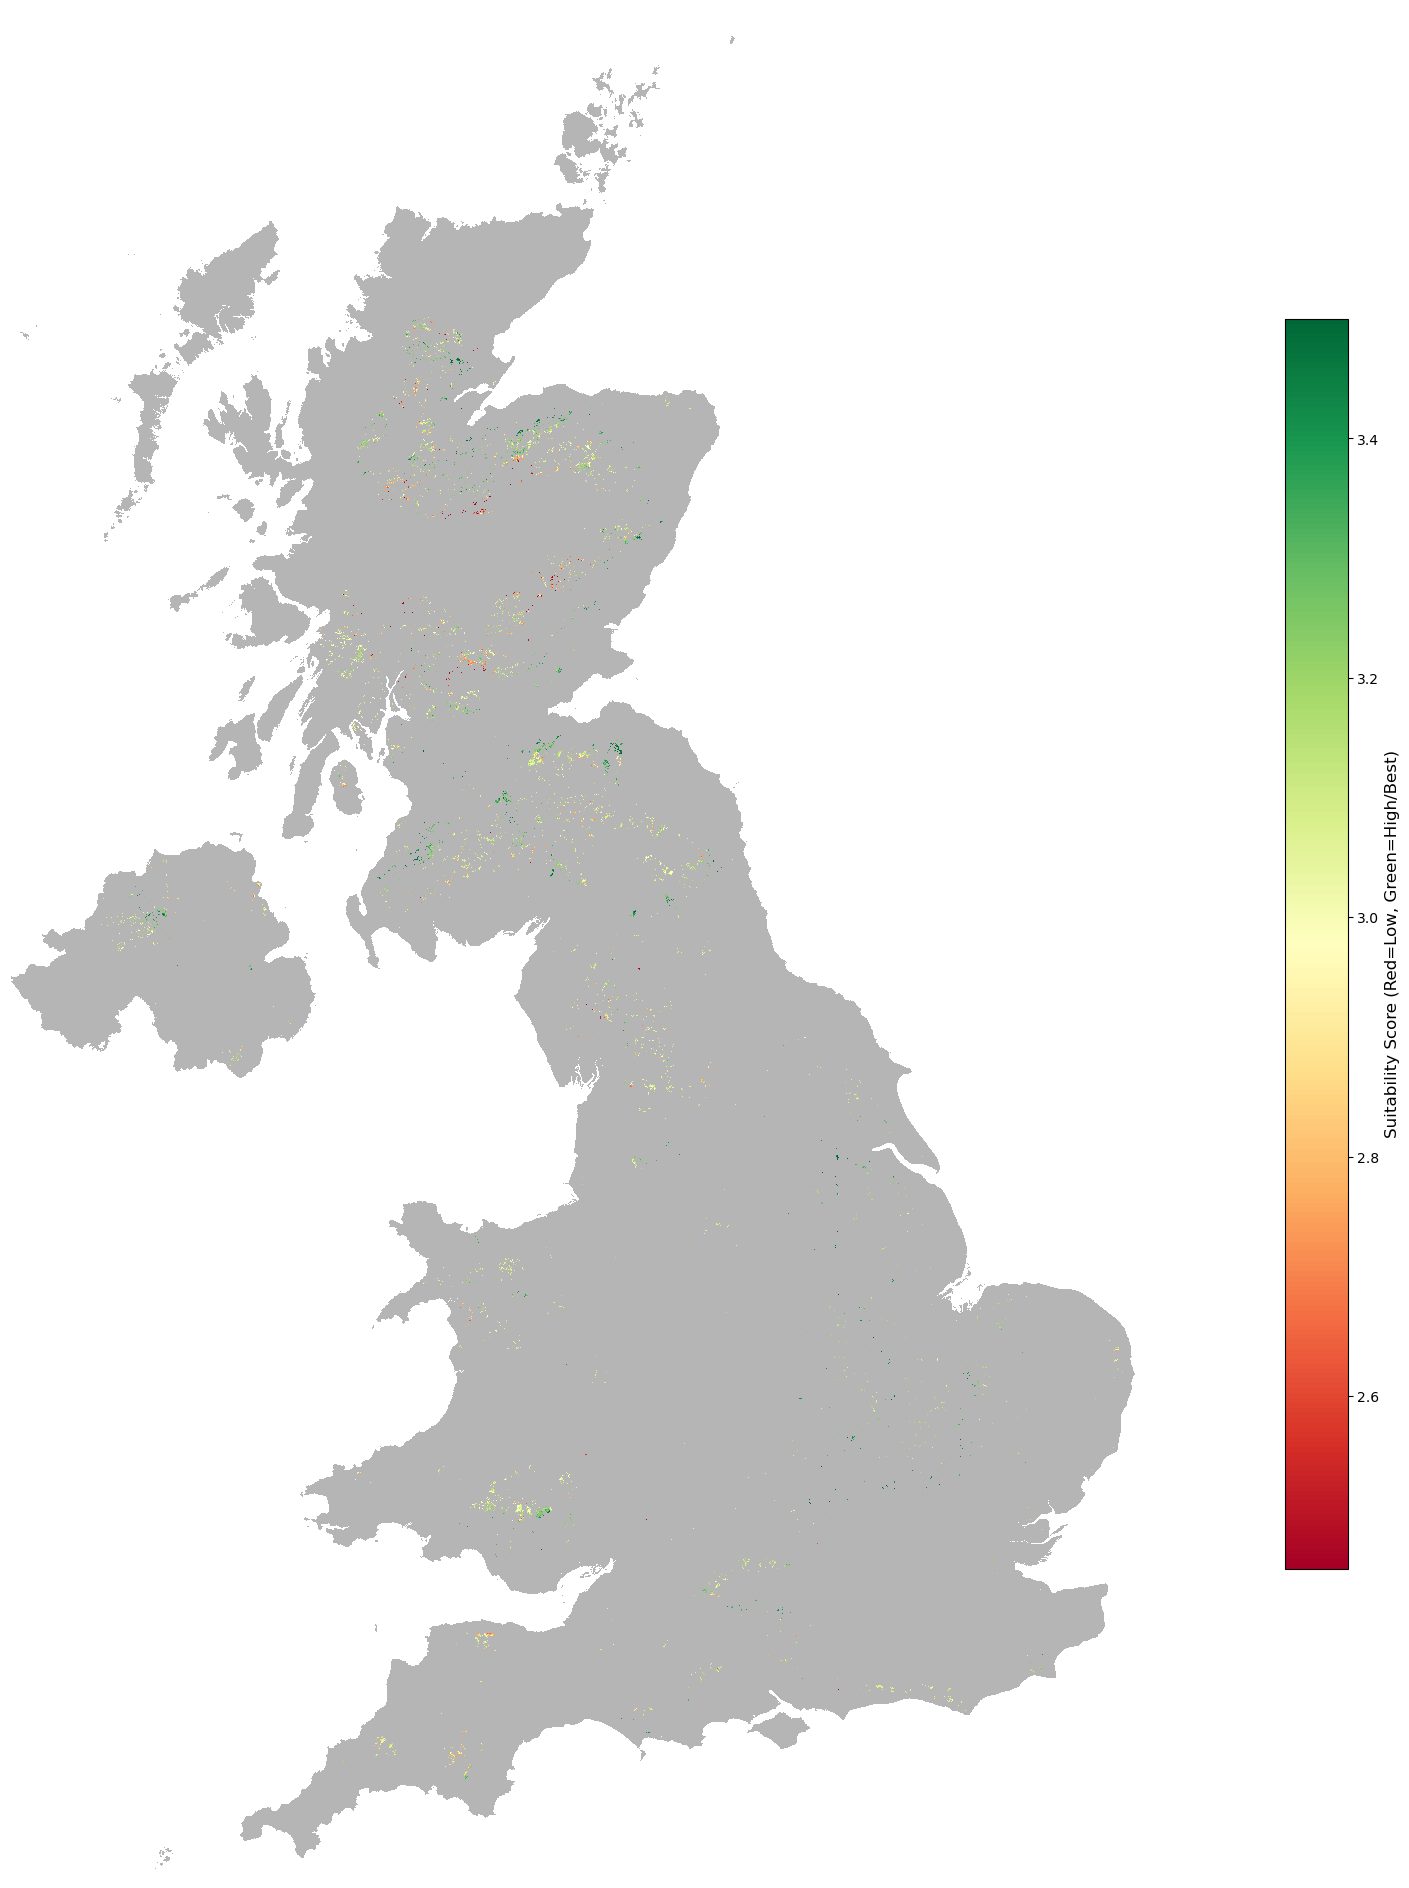

In [36]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import copy
import os

# 1. PFADE DEFINIEREN
# ==========================================
output_folder = '/Users/webshape/Library/Mobile Documents/com~apple~CloudDocs/Dateien/UCL/Spatial Analysis of Energy Data/Assessment 2/Sripts/Output'
tif_path = os.path.join(output_folder, 'UK_Final_Suitability_Score.tif')
outline_path = os.path.join(output_folder, 'UK_Landmass_Outline_100m.tif')

# 2. DATEN LADEN
# ==========================================
with rasterio.open(tif_path) as src_suit:
    suit_data = src_suit.read(1).astype(np.float32)
    suit_extent = [src_suit.bounds.left, src_suit.bounds.right, src_suit.bounds.bottom, src_suit.bounds.top]

with rasterio.open(outline_path) as src_outline:
    outline_data = src_outline.read(1).astype(np.float32)
    outline_extent = [src_outline.bounds.left, src_outline.bounds.right, src_outline.bounds.bottom, src_outline.bounds.top]

# 3. DATEN-VORSORTIERUNG
# ==========================================
suit_data[suit_data <= 0] = np.nan
outline_data[outline_data == 0] = np.nan

valid_values = suit_data[~np.isnan(suit_data)]
vmin_p = np.percentile(valid_values, 1)
vmax_p = np.percentile(valid_values, 99)

# 4. PLOTTEN
# ==========================================
print("Erstelle finale Karte ohne Shetland Islands...")
fig, ax = plt.subplots(figsize=(15, 25))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# LAYER 1: Umriss
ax.imshow(outline_data, 
          cmap='Greys', 
          vmin=0, vmax=2.5, 
          extent=outline_extent, 
          zorder=1, 
          interpolation='none')

# LAYER 2: Eignungs-Scores
cmap = copy.copy(plt.get_cmap('RdYlGn'))
cmap.set_bad(alpha=0.0) 

im = ax.imshow(suit_data, 
               cmap=cmap, 
               vmin=vmin_p, vmax=vmax_p, 
               extent=suit_extent,
               interpolation='none', 
               zorder=2)

# --- FOKUS ANPASSEN (Shetland ausschließen) ---
# Wir setzen das obere Limit auf 1.090.000 (wie in deinem funktionierenden Beispiel)
ax.set_ylim(0, 1090000) 
ax.set_xlim(0, 700000)

# Colorbar
cbar = fig.colorbar(im, ax=ax, shrink=0.5, pad=0.05)
cbar.set_label('Suitability Score (Red=Low, Green=High/Best)', fontsize=12)

ax.set_axis_off()
plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)
ax.margins(0)

# 5. SPEICHERN
# ==========================================
out_file = os.path.join(output_folder, 'UK_Suitability_Final_No_Shetlands.png')
plt.savefig(out_file, dpi=300, bbox_inches='tight', facecolor='white', pad_inches=0)

print(f"Erfolgreich gespeichert unter: {out_file}")

# Save Score Data

In [46]:
import rasterio
import numpy as np
import os

# Pfad definieren (Anpassen, falls nötig)
output_dir = '/Users/webshape/Library/Mobile Documents/com~apple~CloudDocs/Dateien/UCL/Spatial Analysis of Energy Data/Assessment 2/Sripts/Output/'
output_file = os.path.join(output_dir, 'UK_Final_Suitability_Score.tif')

print(f"Speichere Daten nach: {output_file}...")

# 1. Daten vorbereiten (Maskierung auflösen)
# Wir definieren -9999 als "Keine Daten" (Meer/Ausschluss)
nodata_val = -9999.0

if np.ma.is_masked(final_score_masked):
    # Füllt maskierte Bereiche mit -9999
    data_to_save = final_score_masked.filled(nodata_val)
else:
    # Falls es normale NaNs sind
    data_to_save = final_score_masked.copy()
    data_to_save[np.isnan(data_to_save)] = nodata_val

# 2. Metadaten vorbereiten
# Wir nehmen die originalen Metadaten und passen sie an
save_meta = out_meta.copy()
save_meta.update({
    "driver": "GTiff",
    "height": data_to_save.shape[0],
    "width": data_to_save.shape[1],
    "count": 1,
    "dtype": 'float32',
    "nodata": nodata_val,
    "transform": master_transform, # WICHTIG: Die Georeferenzierung
    "compress": "lzw"              # Komprimierung spart Speicherplatz
})

# 3. Schreiben
with rasterio.open(output_file, "w", **save_meta) as dest:
    dest.write(data_to_save.astype('float32'), 1)

print("✅ Datei erfolgreich gespeichert!")

Speichere Daten nach: /Users/webshape/Library/Mobile Documents/com~apple~CloudDocs/Dateien/UCL/Spatial Analysis of Energy Data/Assessment 2/Sripts/Output/UK_Final_Suitability_Score.tif...
✅ Datei erfolgreich gespeichert!
